CONVERT DATASET

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
input_file = "/content/drive/MyDrive/Colab_Notebooks/datasets/apache_logs.txt"
json_output = "/content/drive/MyDrive/Colab_Notebooks/datasets/apache_logs.json"
csv_output = "/content/drive/MyDrive/Colab_Notebooks/datasets/apache_logs.csv"
apache_df = pd.read_csv(csv_output)

In [ ]:
import re
import json
import csv

# Regex cho Apache/Nginx Combined Log Format
log_pattern = re.compile(
    r'(\S+) (\S+) (\S+) \[(.*?)\] '
    r'"(\S+) (.*?) (\S+)" '
    r'(\d{3}) (\S+) '
    r'"(.*?)" "(.*?)"'
)

logs = []

with open(input_file, "r", encoding="utf-8") as f:
    for line in f:
        match = log_pattern.match(line)
        if match:
            log_dict = {
                "ip": match.group(1),
                "identity": match.group(2),
                "user": match.group(3),
                "timestamp": match.group(4),
                "method": match.group(5),
                "url": match.group(6),
                "protocol": match.group(7),
                "status": int(match.group(8)),
                "bytes": 0 if match.group(9) == '-' else int(match.group(9)),
                "referrer": match.group(10),
                "user_agent": match.group(11)
            }
            logs.append(log_dict)

# ----- Ghi JSON -----
with open(json_output, "w", encoding="utf-8") as jf:
    json.dump(logs, jf, indent=4)

# ----- Ghi CSV -----
if logs:
    keys = logs[0].keys()

    with open(csv_output, "w", newline="", encoding="utf-8") as cf:
        writer = csv.DictWriter(cf, fieldnames=keys)
        writer.writeheader()
        writer.writerows(logs)

print("Chuyển đổi hoàn tất.")


Chuyển đổi hoàn tất.


1. DATA PREPROCESSING (Tiền xử lý)

In [5]:
# chuẩn hóa dữ liệu về khoảng [0,1]

# chia nhỏ các chuỗi log bằng sliding windowclass LogDataLoader:

from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import torch

class LogDataLoader:
    def __init__(self, data_path, seq_length=10):
        # load dữ liệu từ CSV hoặc Elasticsearch JSON
        # Dữ liệu mạng thường là các con số (packet size, rate, entropy)

        self.seq_length = seq_length
        self.data_path = data_path
        self.raw_data = None
        self.scaler = MinMaxScaler()
        self.original_df_subset = None

        if data_path:
          self.raw_data = pd.read_csv(data_path) # gọi API từ Elasticsearch thay vì pd.read_csv

    def normalize(self, data):
        return self.scaler.fit_transform(data)

    def create_sliding_windows(self, data):
        # mảng 1D thành các windows (ví dụ: [Batch, seq_length, Features])
        # để Transformer hiểu được "ngữ cảnh" theo thời gian

        windows = []
        for i in range(len(data) - self.seq_length + 1):
          window = data[i : i + self.seq_length]
          windows.append(window)

        return np.array(windows)

    def get_tensor_data(self, df=None):
      working_df = df if df is not None else self.raw_data

      if 'method' in working_df.columns:
        working_df['method_cat'] = working_df['method'].astype('category').cat.codes

      if 'url' in working_df.columns:
        working_df['url_length'] = working_df['url'].apply(len)

      if 'timestamp' in working_df.columns:
        # Định dạng timestamp Apache: [11/Mar/2026:19:10:42 +0700]
        working_df['hour'] = pd.to_datetime(
            working_df['timestamp'],
            format='%d/%b/%Y:%H:%M:%S %z',
            exact=False
        ).dt.hour

      selected_features = ['status', 'bytes', 'method_cat', 'url_length', 'hour']

      for col in selected_features:
        if col not in working_df.columns:
          working_df[col] = 0

      numeric_data = working_df[selected_features].fillna(0).values

      normalized_data = self.normalize(numeric_data)

      sliding_windows = self.create_sliding_windows(normalized_data)
      # ĐỒNG BỘ HÓA: Lưu lại thông tin gốc (IP, Time) khớp với số lượng cửa sổ
      # Do dùng sliding window, dòng i của Tensor sẽ ứng với thông tin ở dòng i + seq_length - 1
      self.original_df_subset = working_df[['ip', 'timestamp']].iloc[self.seq_length -1:].reset_index(drop=True)

      return torch.tensor(sliding_windows, dtype=torch.float32)


2. Transformer-VAE Class

In [6]:
# self-attention layer

# mean và các log-variance layer: các lớp tuyến tính để tính toán
# $\mu$ và $\sigma$ của không gian tìm ẩn (latent space)

# reparameterization function: lấy mẫu (sampling) từ phân phối xác suất

import torch
import torch.nn as nn

class TransformerVAE(nn.Module):
    def __init__(self, feature_size, seq_length, latent_dim, nhead=2, num_layers=2):
        super(TransformerVAE, self).__init__()
        # Khai báo nn.TransformerEncoder và nn.TransformerDecoder
        # Sử dụng nn.Linear để tạo tầng mu và logvar cho Latent Space
        self.feature_size = feature_size
        self.seq_length = seq_length

        encoder_layer = nn.TransformerEncoderLayer(d_model=feature_size, nhead=nhead, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.fc_mu = nn.Linear(feature_size * seq_length, latent_dim)
        self.fc_logvar = nn.Linear(feature_size * seq_length, latent_dim)

        self.decoder_input = nn.Linear(latent_dim, feature_size * seq_length)
        decoder_layer = nn.TransformerDecoderLayer(d_model=feature_size, nhead=nhead, batch_first=True)
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)

        self.fc_final = nn.Linear(feature_size, feature_size)

    def encode(self, x):
        # Pass x qua TransformerEncoder -> Flatten -> mu & logvar
        # x shape: [batch, seq_length, feature_size]
        h = self.transformer_encoder(x)
        h_flat = h.view(h.size(0), -1)

        mu = self.fc_mu(h_flat)
        logvar = self.fc_logvar(h_flat)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        # hàm lấy mẫu ngẫu nhiên (sampling) để tạo biến z
        # z = mu + epsilon * exp(0.5 * logvar)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std) # nhiễu ngẫu nhiên gausian
        return mu + eps * std

    def decode(self, z):
        # Pass z qua TransformerDecoder để tái tạo lại chuỗi log ban đầu

        # 1. Chuyển z về lại dạng chuỗi [Batch, Seq_Len, Feature_Size]
        z_projected = self.decoder_input(z).view(-1, self.seq_length, self.feature_size)

        # 2. Sử dụng Transformer Decoder (trong VAE đơn giản có thể dùng chính z làm memory)
        out = self.transformer_decoder(z_projected, z_projected)
        return self.fc_final(out)

    def forward(self, x):
      # encode -> reparameterize -> decode
      mu, logvar = self.encode(x)
      z = self.reparameterize(mu, logvar)
      recon_x = self.decode(z)
      return recon_x, mu, logvar


3. Loss Function (Hàm mất mát)

In [7]:
# mse loss

# knullback-leibler divergence (kld)

import torch
import torch.nn as nn

def calculate_loss(recon_x, x, mu, logvar, beta=1.0):
    # Công thức: Loss = Reconstruction_Loss + KLD_Loss

    # Tính MSE giữa recon_x và x (đo sai số tái tạo)
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='mean')

    # Tính KL Divergence (đo mức độ lệch giữa phân phối học được và chuẩn N(0,1))
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    total_loss = recon_loss + beta * kld_loss
    return total_loss, recon_loss, kld_loss


4. Uncertainty Calculator (Bộ đo dộ bất định)

In [8]:
# vòng lặp huấn luyện (training loop)

# tính phương sai (variance)

import torch
import numpy as np

def get_uncertainty(model, data, num_passes=20):
    # Sử dụng Kỹ thuật MC Dropout
    # Bật model.train() để kích hoạt Dropout ngẫu nhiên, chạy dự đoán 'num_passes' lần

    model.train()

    predictions = []

    with torch.no_grad():
      for i in range(num_passes):
        recon_batch, _, _ = model(data)
        predictions.append(recon_batch.cpu().numpy())

    # [số lần chạy, batch, seq_length, feature_size]
    predictions = np.array(predictions)

    uncertainty_map = np.var(predictions, axis=0)

    total_uncertainty = np.mean(uncertainty_map, axis=(1, 2))
    return total_uncertainty

    # Tính phương sai (variance) của các dự đoán
    # Phương sai càng lớn -> uncertainty càng cao (đây chính là dấu hiệu kịch bản mới)

In [10]:
# ==========================================
# QUY TRÌNH VẬN HÀNH TỔNG THỂ
# ==========================================

# 1. KHỞI TẠO DỮ LIỆU
loader = LogDataLoader(data_path=csv_output, seq_length=10)
# ['status', 'bytes', 'method_cat', 'url_length', 'hour']
X_train = loader.get_tensor_data(df=apache_df) # Chỉ huấn luyện trên traffic sạch

# ==========================================
# GIẢ LẬP DỮ LIỆU TẤN CÔNG
# ==========================================
# Tạo dữ liệu tấn công giả lập từ chính traffic sạch
X_test = X_train.clone()
# Kịch bản giả lập: Tấn công tăng đột biến dung lượng (Bytes)
X_test[:, :, 1] = X_test[:, :, 1] * 5.0  # Tăng dung lượng lên 5 lần bình thường
# Kịch bản giả lập: Tấn công dồn dập vào 1 URL lạ (URL length tăng vọt)
X_test[:, :, 3] = X_test[:, :, 3] + 0.8  # Đưa giá trị normalized lên gần mức 1.0
# ==========================================

# 2. KHỞI TẠO MÔ HÌNH
feature_size = X_train.shape[2]
model = TransformerVAE(feature_size=feature_size, seq_length=10, latent_dim=4, nhead=1).cuda()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 3. HUẤN LUYỆN
print("--- Bắt đầu huấn luyện mô hình ---")
model.train()
for epoch in range(200):
    optimizer.zero_grad()
    recon, mu, logvar = model(X_train.cuda())
    loss, r_loss, k_loss = calculate_loss(recon, X_train.cuda(), mu, logvar)
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4f} (Recon: {r_loss.item():.4f}, KLD: {k_loss.item():.4f})")

# 4. ĐÁNH GIÁ & TÍNH UNCERTAINTY
print("\n--- Đang thực hiện suy luận và tính toán Uncertainty ---")
# Tính sai số tái tạo để phát hiện bất thường
model.eval()
with torch.no_grad():
    recon_test, mu_test, logvar_test = model(X_test.cuda())
    # Tính MSE từng mẫu (error per sample)
    errors = torch.mean((recon_test - X_test.cuda())**2, dim=(1,2)).cpu().numpy()

# Tính độ bất định bằng MC Dropout
uncertainties = get_uncertainty(model, X_test.cuda(), num_passes=20)



/tmp/ipykernel_8392/2463754621.py:20: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


--- Bắt đầu huấn luyện mô hình ---
Epoch 0: Loss = 9268.9238 (Recon: 0.3180, KLD: 9268.6055)
Epoch 10: Loss = 1258.1885 (Recon: 0.0650, KLD: 1258.1235)
Epoch 20: Loss = 494.5175 (Recon: 0.0478, KLD: 494.4698)
Epoch 30: Loss = 504.9151 (Recon: 0.0405, KLD: 504.8746)
Epoch 40: Loss = 396.5235 (Recon: 0.0359, KLD: 396.4876)
Epoch 50: Loss = 322.7776 (Recon: 0.0329, KLD: 322.7447)
Epoch 60: Loss = 267.0869 (Recon: 0.0305, KLD: 267.0564)
Epoch 70: Loss = 197.3891 (Recon: 0.0291, KLD: 197.3600)
Epoch 80: Loss = 126.4028 (Recon: 0.0281, KLD: 126.3748)
Epoch 90: Loss = 79.7361 (Recon: 0.0272, KLD: 79.7089)
Epoch 100: Loss = 60.4641 (Recon: 0.0263, KLD: 60.4378)
Epoch 110: Loss = 50.9685 (Recon: 0.0256, KLD: 50.9430)
Epoch 120: Loss = 44.4095 (Recon: 0.0248, KLD: 44.3847)
Epoch 130: Loss = 37.9198 (Recon: 0.0240, KLD: 37.8958)
Epoch 140: Loss = 33.3699 (Recon: 0.0234, KLD: 33.3465)
Epoch 150: Loss = 29.6302 (Recon: 0.0230, KLD: 29.6072)
Epoch 160: Loss = 26.0283 (Recon: 0.0227, KLD: 26.0056)
Ep

5. Visualization (Trực quan hóa)

In [9]:
# biểu đồ đường cho reconstruction error

# biểu đồ cột so sánh mức độ bất định (uncertainty) giữa các kịch bản tấn công

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

def plot_results(reconstruction_error, uncertainty_scores, latent_z=None, labels=None):
    # biểu đồ đường (Line plot) cho lỗi tái tạo theo thời gian
    # biểu đồ Scatter cho Latent Space (Z) để xem "cụm" bình thường và "cụm" tấn công

    plt.figure(figsize=(15, 5))
    # 1. BIỂU ĐỒ LỖI TÁI TẠO (RECONSTRUCTION ERROR)
    # đường line cho thấy sự vọt lên của lỗi khi gặp tấn công
    plt.subplot(1, 2, 1)
    plt.plot(reconstruction_error, label='Reconstruction Error', color='blue', alpha=0.6)
    threshold = np.mean(reconstruction_error) + 2 * np.std(reconstruction_error)
    plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
    plt.title('Phát hiện bất thường qua Sai số tái tạo - Reconstruction error')
    plt.xlabel('Mẫu dữ liệu (Time)')
    plt.ylabel('MSE Loss')

    # 2. BIỂU ĐỒ ĐỘ BẤT ĐỊNH (UNCERTAINTY BAR)
    # So sánh Uncertainty giữa các kịch bản bằng Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=labels, y=uncertainty_scores)
    plt.title('Độ bất định (Uncertainty) theo từng kịch bản')
    plt.xlabel('Normal, Unknown')
    plt.ylabel('Uncertainty Score')

    plt.tight_layout()
    plt.show()

    # 3. BIỂU ĐỒ KHÔNG GIAN TIỀM ẨN (LATENT SPACE SCATTER)
    # Nếu có dữ liệu Latent Z, ta dùng t-SNE để giảm chiều về 2D
    if latent_z is not None and labels is not None:
      tsne = TSNE(n_components=2, perplexity=30, n_iter=300)
      z_2d = tsne.fit_transform(latent_z)

      plt.figure(figsize=(8, 6))
      # Chuyển đổi labels chữ thành số để máy hiểu màu sắc
      label_ids, label_names = pd.factorize(labels)

      scatter = plt.scatter(z_2d[:, 0], z_2d[:, 1], c=label_ids, cmap='viridis', alpha=0.7)

      cbar = plt.colorbar(scatter)
      cbar.set_ticks(range(len(label_names)))
      cbar.set_ticklabels(label_names)

      plt.title('Trực quan hóa không gian tiềm ẩn (t-SNE)')
      plt.show()

AUTO-LABELING

In [ ]:
# threshold_re # ngưỡng của lỗi tái tạo
# threshold_u # ngưỡng của độ bất định
def auto_labeler(errors, uncertainties, threshold_re, threshold_u):
    """
    Logic:
    - RE thấp: Normal
    - RE cao, Uncertainty thấp: Known Anomaly (Kịch bản 1-4, cũ)
    - RE cao, Uncertainty cao: Unknown Attack (Kịch bản 5, mới)
    """
    labels = []
    for e, u in zip(errors, uncertainties):
        if e > threshold_re:
            if u > threshold_u:
                labels.append("Unknown Attack")
            else:
                labels.append("Known Anomaly")
        else:
            labels.append("Normal")
    return np.array(labels)

--- Đang vẽ biểu đồ kết quả ---
Số lượng lỗi: 9977
Số lượng độ bất định: 9977
Số lượng nhãn: 9977


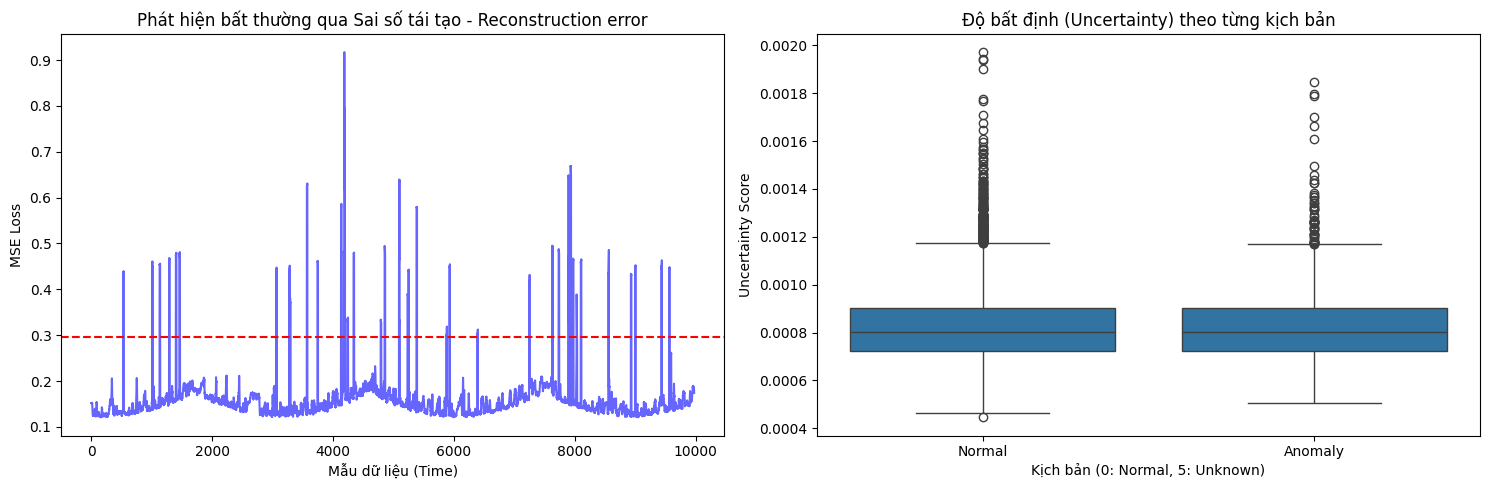

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


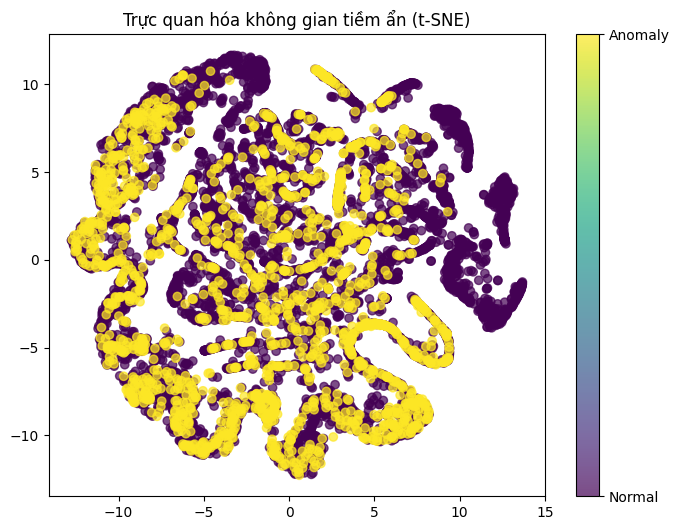

In [11]:
# 5. TRỰC QUAN HÓA (KHỐI 5)
print("--- Đang vẽ biểu đồ kết quả ---")
# X_test có kích thước [Số_cửa_sổ, seq_length, feature_size]
num_windows = X_test.shape[0]

# Tạo nhãn giả lập khớp với số lượng cửa sổ
# Ví dụ: 80% đầu là Normal, 20% sau là Anomaly
labels_test = np.array(['Normal'] * int(num_windows * 0.8) + ['Anomaly'] * (num_windows - int(num_windows * 0.8)))

# Kiểm tra lại độ dài trước khi vẽ
print(f"Số lượng lỗi: {len(errors)}")
print(f"Số lượng độ bất định: {len(uncertainties)}")
print(f"Số lượng nhãn: {len(labels_test)}")
plot_results(errors, uncertainties, latent_z=mu_test.cpu().numpy(), labels=labels_test)

ĐÓNG GÓI DỮ LIỆU ĐÃ GÁN NHÃN & GỬI VỀ CHO ELASTICSEARCH

In [ ]:
from elasticsearch import Elasticsearch
import json

# Khởi tạo Elasticsearch client
# điền thông tin kết nối của cluster Elasticsearch
# es = Elasticsearch(
#     cloud_id="YOUR_CLOUD_ID",
#     api_key=("YOUR_API_KEY_ID", "YOUR_API_KEY_SECRET")
# )
# HOẶC nếu có cluster tự host:
# es = Elasticsearch(
#     ['http://localhost:9200'], # Thay đổi bằng địa chỉ và port của Elasticsearch instance
#     # http_auth=('user', 'password'), # Nếu có xác thực
#     # verify_certs=False, # Chỉ dùng trong môi trường dev, không khuyến khích trong production
# )
# Thay thế bằng thông tin thực tế
es = None # Placeholder

# Tên index để lưu dữ liệu log
ELASTICSEARCH_INDEX = "anomaly_logs_v2" # có thể thay đổi tên index này

In [ ]:
import json

def package_to_elk(loader, uncertainties, errors, labels):
    """
    Đóng gói dữ liệu và gửi đến Elasticsearch.
    Yêu cầu biến 'es' (Elasticsearch client) và 'ELASTICSEARCH_INDEX' đã được khởi tạo.
    """
    meta_data = loader.original_df_subset
    results_to_send = []

    for i in range(len(labels)):
        if labels[i] != "Normal":
            record = {
                "timestamp": meta_data.iloc[i]['timestamp'],
                "ip_source": meta_data.iloc[i]['ip'],
                "recon_error": float(errors[i]),
                "uncertainty": float(uncertainties[i]),
                "predicted_label": labels[i],
                "status": "pending_review" # Trạng thái chờ chuyên gia xác nhận
            }
            results_to_send.append(record)

    if results_to_send:
        if es is None: # Kiểm tra xem client Elasticsearch đã được khởi tạo chưa
            print("Lỗi: Elasticsearch client chưa được khởi tạo. Vui lòng cấu hình 'es'.")
            return None

        print(f"--- Đang gửi {len(results_to_send)} cảnh báo đến Elasticsearch index: {ELASTICSEARCH_INDEX} ---")
        try:
            # Sử dụng bulk helper để gửi nhiều tài liệu hiệu quả hơn
            from elasticsearch.helpers import bulk
            actions = [
                {
                    "_index": ELASTICSEARCH_INDEX,
                    "_source": doc
                }
                for doc in results_to_send
            ]
            success, failed = bulk(es, actions)
            print(f"--- Đã gửi thành công {success} tài liệu, {failed} tài liệu lỗi. ---")
            return True # Trả về True nếu thành công
        except Exception as e:
            print(f"Lỗi khi gửi dữ liệu đến Elasticsearch: {e}")
            return False # Trả về False nếu có lỗi
    else:
        print("Không có cảnh báo nào để gửi.")
        return None

VÒNG LẶP TỰ HỌC -> KỊCH BẢN MỚI -> KỊCH BẢN QUEN

In [ ]:
# khi 1 mẫu dữ liệu mới đạt số lượng nhất định
# -> tiến hành cho mô hình học thêm
# để biến kịch bản mới gặp -> kịch bản quen thuộc

import os

def self_learning_process(model, optimizer, new_patterns, save_path="models/fine_tuned_model.pth", queue_limit=100):
    if len(new_patterns) < queue_limit: # Cần ít nhất 100 mẫu mới để tránh overfitting
        return False

    print(f"--- Đang học từ {len(new_patterns)} mẫu kịch bản mới... ---")
    model.train()

    # Chuyển dữ liệu mới thành Tensor Dataset
    new_data_tensor = torch.tensor(new_patterns, dtype=torch.float32).cuda()

    # Fine-tuning nhanh trong 10-20 epochs
    for epoch in range(20):
        optimizer.zero_grad()
        recon, mu, logvar = model(new_data_tensor)
        loss, _, _ = calculate_loss(recon, new_data_tensor, mu, logvar)
        loss.backward()
        optimizer.step()

    # Lưu lại phiên bản mô hình mới
    torch.save(model.state_dict(), save_path)
    print(f"--- Đã cập nhật mô hình tại {save_path} ---")
    return True